# Вариант №1.

# Базовая настройка

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import math as m
import statsmodels.api as sm
from IPython.display import display, Markdown

In [4]:
variant = 1

def mprint(*strings):  
    for s in strings:
        display(Markdown(s))


def dataframe_to_markdown(df):
    if df.index.name is None:
        first_cell = "Index"
    elif df.columns.name is None:
        first_cell = df.index.name
    else:
        first_cell = df.index.name + "\\" + df.columns.name
    markdown_table = "| " + first_cell + " | " + " | ".join(df.columns) + " |\n"
    markdown_table += "|---" * (len(df.columns) + 1) + "|\n"  # Учитываем индекс

    for index, row in df.iterrows():
        row_values = [str(round(val, 2) if type(val) != str else val) for val in row]
        markdown_table += f"| {index} | " + " | ".join(row_values) + " |\n"

    return markdown_table

mpl.rcParams["text.usetex"] = False


# можно выводить latex в надписях matplotlib
plt.rc("text", usetex=True)
plt.rc(
    "text.latex",
    preamble=r"""
\usepackage[english, russian]{babel}
\usepackage[utf8]{inputenc}
""",
)
plt.style.use("seaborn-v0_8")

path_to_vars = "../bdz_vars.xls"
path_to_data = "../bdz_data.xls"

In [5]:
datas = pd.read_excel(path_to_vars, index_col=0).loc[variant]

variant_dict = dict()
for tasks in datas.index:
    for task in tasks.split(", "):
        variant_dict[task] = (
            datas[tasks]
            .replace("А", "A")
            .replace("В", "B")
            .replace("С", "C")
            .split(" ")
        )

In [6]:
dfs = pd.read_excel(path_to_data, sheet_name=None)
sheet_dict = dict()
for value in list(dfs.keys())[1:]:
    key = value[0]
    sheet_dict[key] = value

def data(task):
    X = []
    for data in variant_dict[task]:
        sheet = data[0]
        column = data
        df = dfs[sheet_dict[sheet]][column]
        X.append(df)
    return X

def verdict(alpha, p_value):
    if alpha > p_value:
        return "$H_0$ отклоняется"
    else:
        return "$H_0$ принимается"

# 1. Описательные статистики

## 1.1 Выборочные характеристики


In [7]:
columns = data("1.1")

for i, X in enumerate(columns, start=1):
    mean_ = X.mean()
    D = X.var(ddof=0)
    d = X.std(ddof=0)
    g = stats.skew(X, bias=True)
    e = stats.kurtosis(X, bias=True)
    output = f"$\\mathbf{{X_{i}}}:$ \
        $\\overline x_{i} =$ {mean_:.2f}; \
        $D^*_{{X_{i}}} =$ {D:.2f}; \
        $\\sigma^*_{{X_{i}}} =$ {d:.2f}; \
        $\\gamma^*_{{X_{i}}} =$ {g:.2f}; \
        $\\varepsilon^*_{{X_{i}}} =$ {e:.2f} \
        "
    
    mprint(output)

$\mathbf{X_1}:$         $\overline x_1 =$ 526.48;         $D^*_{X_1} =$ 13855.93;         $\sigma^*_{X_1} =$ 117.71;         $\gamma^*_{X_1} =$ 0.68;         $\varepsilon^*_{X_1} =$ 0.53         

$\mathbf{X_2}:$         $\overline x_2 =$ 420.04;         $D^*_{X_2} =$ 4953.14;         $\sigma^*_{X_2} =$ 70.38;         $\gamma^*_{X_2} =$ 0.35;         $\varepsilon^*_{X_2} =$ 0.18         

$\mathbf{X_3}:$         $\overline x_3 =$ 355.09;         $D^*_{X_3} =$ 2901.58;         $\sigma^*_{X_3} =$ 53.87;         $\gamma^*_{X_3} =$ 0.45;         $\varepsilon^*_{X_3} =$ 0.43         

## 1.2 Группировка и гистограммы частот

In [8]:
X = data("1.2")[0]
n = len(X)

X = pd.DataFrame(X.values, columns=["value"])
maximum = max(X["value"])
minimum = min(X["value"])
k = round(1 + 3.322 * m.log10(n))

mprint(f"$\\mathbf{{X}}: \\max = {maximum}, \\min = {minimum}, n = {n}, k = {k}$")

$\mathbf{X}: \max = 1009, \min = 270, n = 1073, k = 11$

In [84]:
X["group"] = pd.cut(X["value"], bins=k)

delta_min = np.min(
    [interval.right - interval.left for interval in X["group"].cat.categories]
)
delta_max = np.max(
    [interval.right - interval.left for interval in X["group"].cat.categories]
)

mprint(f"Ширина интервалов: от {delta_min:.2f} до {delta_max:.2f}")

Ширина интервалов: от 67.18 до 67.92

In [85]:
groups = pd.DataFrame(index=pd.Index(range(1, k + 1), name="Номер интервала"))
groups["low edge"] = [interval.left for interval in X["group"].cat.categories]
groups["high edge"] = [interval.right for interval in X["group"].cat.categories]
groups["frequency"] = X["group"].value_counts().sort_index().values
groups["relative frequency"] = groups["frequency"] / n
groups["cumulative frequency"] = groups["frequency"].cumsum()
groups["cumulative relative frequency"] = groups["cumulative frequency"] / n

print(dataframe_to_markdown(groups))

| Номер интервала | low edge | high edge | frequency | relative frequency | cumulative frequency | cumulative relative frequency |
|---|---|---|---|---|---|---|
| 1 | 269.26 | 337.18 | 28.0 | 0.03 | 28.0 | 0.03 |
| 2 | 337.18 | 404.36 | 118.0 | 0.11 | 146.0 | 0.14 |
| 3 | 404.36 | 471.55 | 227.0 | 0.21 | 373.0 | 0.35 |
| 4 | 471.55 | 538.73 | 277.0 | 0.26 | 650.0 | 0.61 |
| 5 | 538.73 | 605.91 | 171.0 | 0.16 | 821.0 | 0.77 |
| 6 | 605.91 | 673.09 | 123.0 | 0.11 | 944.0 | 0.88 |
| 7 | 673.09 | 740.27 | 80.0 | 0.07 | 1024.0 | 0.95 |
| 8 | 740.27 | 807.46 | 31.0 | 0.03 | 1055.0 | 0.98 |
| 9 | 807.46 | 874.64 | 7.0 | 0.01 | 1062.0 | 0.99 |
| 10 | 874.64 | 941.82 | 7.0 | 0.01 | 1069.0 | 1.0 |
| 11 | 941.82 | 1009.0 | 4.0 | 0.0 | 1073.0 | 1.0 |



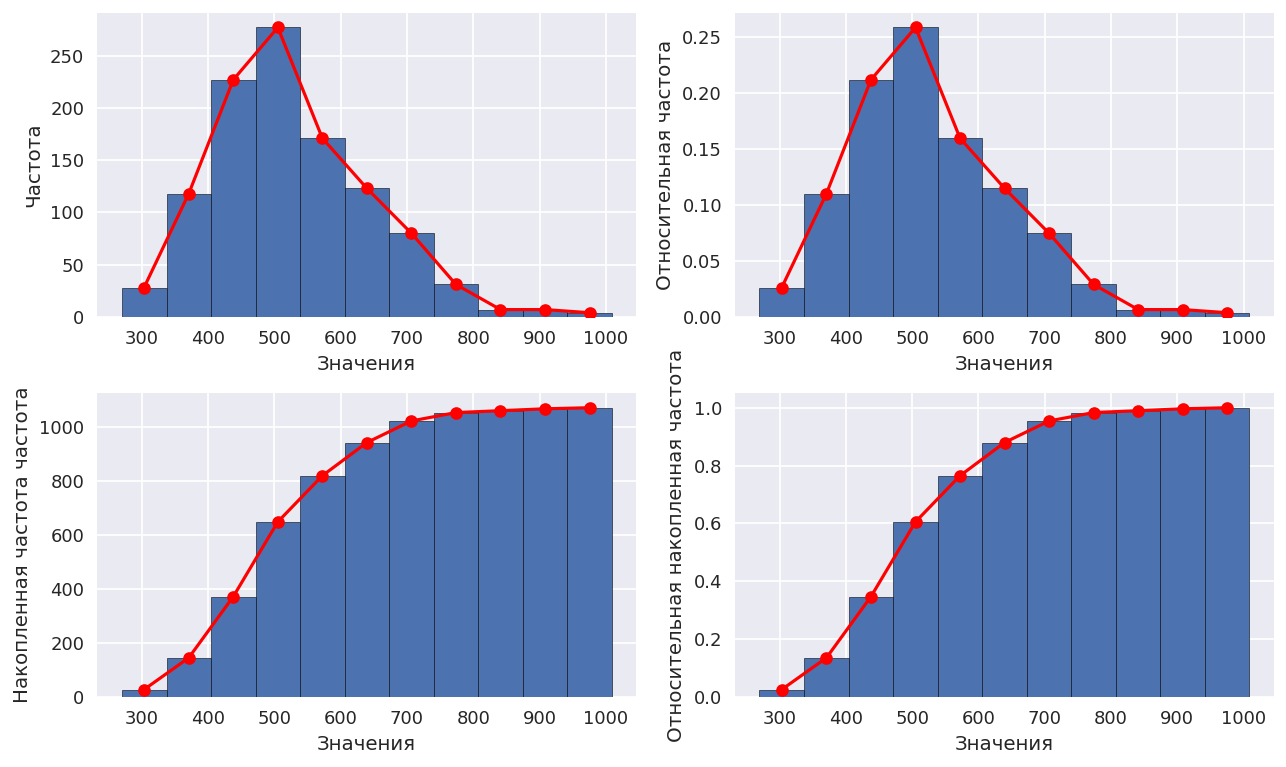

In [86]:
bin_centers = (groups["low edge"] + groups["high edge"]) / 2
width = groups["high edge"] - groups["low edge"]

mpl.rcParams.update({
    "text.usetex": False,
    "axes.unicode_minus": False,
    "font.family": "DejaVu Sans",
    "figure.dpi": 130,
})

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].bar(
    bin_centers,
    groups["frequency"],
    width=width,
    edgecolor="black",
)
axes[0, 0].plot(bin_centers, groups["frequency"], marker="o", color="r")
axes[0, 0].set_xlabel("Значения")
axes[0, 0].set_ylabel("Частота")

axes[0, 1].bar(
    bin_centers,
    groups["relative frequency"],
    width=width,
    edgecolor="black",
)
axes[0, 1].plot(bin_centers, groups["relative frequency"], marker="o", color="r")
axes[0, 1].set_xlabel("Значения")
axes[0, 1].set_ylabel("Относительная частота")


axes[1, 0].bar(
    bin_centers,
    groups["cumulative frequency"],
    width=width,
    edgecolor="black",
)
axes[1, 0].plot(bin_centers, groups["cumulative frequency"], marker="o", color="r")
axes[1, 0].set_xlabel("Значения")
axes[1, 0].set_ylabel("Накопленная частота частота")


axes[1, 1].bar(
    bin_centers,
    groups["cumulative relative frequency"],
    width=width,
    edgecolor="black",
)
axes[1, 1].plot(
    bin_centers, groups["cumulative relative frequency"], marker="o", color="r"
)
axes[1, 1].set_xlabel("Значения")
axes[1, 1].set_ylabel("Относительная накопленная частота")

plt.tight_layout()
plt.show()

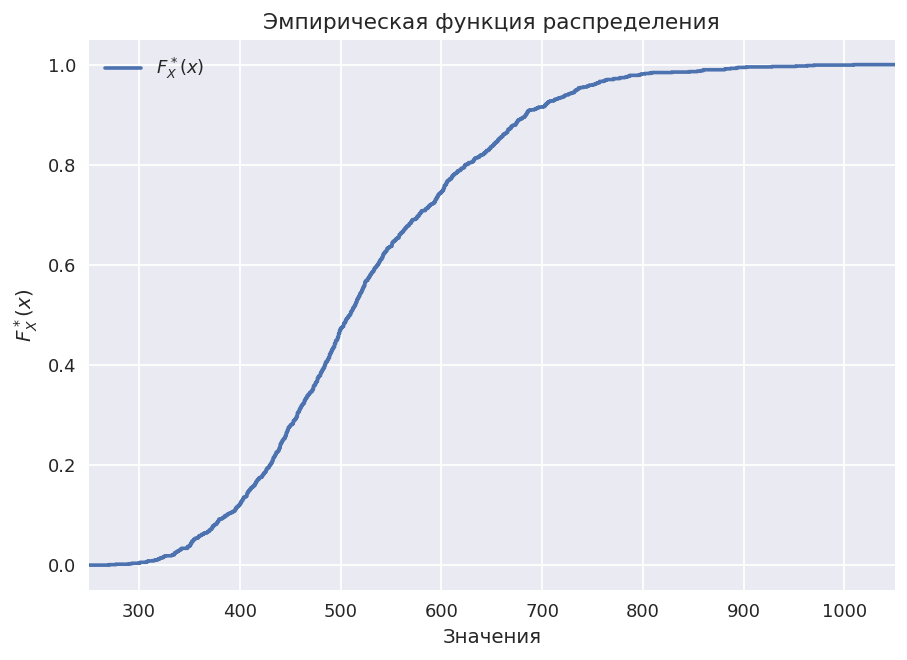

In [87]:
X_sorted = np.sort(X["value"])
X_sorted = np.concatenate(([-10000], X_sorted, [10000]))
F = np.arange(1, n + 1) / n
F = np.concatenate(([0], F, [1]))
plt.step(X_sorted, F, where="post", label=r"$F_X^*(x)$", linewidth=2)
plt.xlim(250, 1050)
plt.xlabel("Значения")
plt.ylabel("$F^*_X(x)$")
plt.legend()
plt.title("Эмпирическая функция распределения")
plt.show()

# 2. Интервальные оценки

## 2.1 Доверительные интервалы для математического ожидания


In [76]:
X = data("2.1")[0]
n = len(X)

intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)

alphas = [0.01, 0.05, 0.1]
std_err = stats.sem(X)
for alpha in alphas:
    intervals[f"alpha = {alpha}"] = stats.t.interval(
        1 - alpha, df=n - 1, loc=X.mean(), scale=std_err
    )
    
print(dataframe_to_markdown(intervals))

| Граница доверительного интервала | alpha = 0.01 | alpha = 0.05 | alpha = 0.1 |
|---|---|---|---|
| Нижняя граница | 517.21 | 519.43 | 520.57 |
| Верхняя граница | 535.76 | 533.54 | 532.4 |



## 2.2 Доверительные интервалы для дисперсии


In [77]:
X = data("2.2")[0]
n = len(X)

intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    chi2_upper, chi2_lower = stats.chi2.interval(1 - alpha, df=n - 1)
    intervals[f"alpha = {alpha}"] = [
        (n - 1) * X.var(ddof=1) / chi2_lower,
        (n - 1) * X.var(ddof=1) / chi2_upper,
    ]
    
print(dataframe_to_markdown(intervals))

| Граница доверительного интервала | alpha = 0.01 | alpha = 0.05 | alpha = 0.1 |
|---|---|---|---|
| Нижняя граница | 12441.11 | 12765.76 | 12936.26 |
| Верхняя граница | 15543.74 | 15122.13 | 14912.28 |



## 2.3 Доверительные интервалы для разности мат. ожиданий

In [71]:
X1, X2 = data("2.3")
n1 = len(X1)
n2 = len(X2)

intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
std_err = m.sqrt(
    ((n1 - 1) * X1.var(ddof=1) + (n2 - 1) * X2.var(ddof=1))
    / (n1 + n2 - 2)
    * (1 / n1 + 1 / n2)
)
for alpha in alphas:
    intervals[f"alpha = {alpha}"] = stats.t.interval(
        1 - alpha, df=n1 + n2 - 2, loc=X1.mean() - X2.mean(), scale=std_err
    )
    
print(dataframe_to_markdown(intervals))

| Граница доверительного интервала | alpha = 0.01 | alpha = 0.05 | alpha = 0.1 |
|---|---|---|---|
| Нижняя граница | 95.64 | 98.23 | 99.55 |
| Верхняя граница | 117.24 | 114.66 | 113.33 |



## 2.4. Доверительные интервалы для отношения дисперсий


In [88]:
X1, X2 = data("2.4")
n1 = len(X1)
n2 = len(X2)

intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    intervals[f"alpha = {alpha}"] = stats.f.interval(
        1 - alpha, dfn=n1 - 1, dfd=n2 - 1, loc=0, scale=X1.var(ddof=1) / X2.var(ddof=1)
    )
    
print(dataframe_to_markdown(intervals))

| Граница доверительного интервала | alpha = 0.01 | alpha = 0.05 | alpha = 0.1 |
|---|---|---|---|
| Нижняя граница | 2.39 | 2.48 | 2.53 |
| Верхняя граница | 3.27 | 3.15 | 3.09 |



# 3. Проверка статистических гипотез о математических ожиданиях и дисперсиях


## 3.1 Проверка статистических гипотез о математических ожиданиях


In [13]:
X = data("3.1")[0]
X.head()

0    454
1    686
2    533
3    612
4    442
Name: A5, dtype: int64

In [14]:
print(n := len(X))


1073


In [25]:
alpha = 0.1
m0_list = [120, 180, 240]

mprint(r"### T-test")
for m0 in m0_list:
    z, p_value = stats.ttest_1samp(X, m0)
    mprint(
        r"---",
        f"$H_0: m = m_0 = {m0}$",
        f"$z_{{выб}} =$ {z:.2f}",
        f"$p =$ {p_value:.2f}",
        verdict(alpha, p_value),
    )

### T-test

---

$H_0: m = m_0 = 120$

$z_{выб} =$ 113.06

$p =$ 0.00

...

---

$H_0: m = m_0 = 240$

$z_{выб} =$ 79.69

$p =$ 0.00

$H_0$ отклоняется

## 3.2 Проверка статистических гипотез о дисперсиях

In [26]:
X = data("3.2")[0]
X.head()

0    454
1    686
2    533
3    612
4    442
Name: A5, dtype: int64

In [27]:
print(n := len(X))

1073


In [28]:
def chisquare(X, value):
    n = len(X)
    z = (n - 1) * X.var(ddof=1) / value**2
    cdf = stats.chi2.cdf(z, df=n - 1)
    p_value = 2 * min(cdf, 1 - cdf)
    return z, p_value

alpha = 0.1
std0_list = [10, 20, 30]

mprint(r"### $\chi^2$-test")
for std0 in std0_list:
    z, p_value = chisquare(X, std0)
    mprint(
        r"---",
        f"$H_0: \\sigma = \\sigma_0 = {std0}$",
        f"$z_{{выб}} =$ {z:.2f}",
        f"$p =$ {p_value:.2f}",
        verdict(alpha, p_value),
    )

### $\chi^2$-test

---

$H_0: \sigma = \sigma_0 = 10$

$z_{выб} =$ 148674.14

$p =$ 0.00

...

---

$H_0: \sigma = \sigma_0 = 30$

$z_{выб} =$ 16519.35

$p =$ 0.00

$H_0$ отклоняется

## 3.3 Проверка статистических гипотез о равенстве математических ожиданий

In [18]:
X1, X2 = data("3.3")
X1.head(), X2.head()

(0    454
 1    686
 2    533
 3    612
 4    442
 Name: A5, dtype: int64,
 0    382
 1    560
 2    494
 3    507
 4    369
 Name: A6, dtype: int64)

In [19]:
print(n1 := len(X1), n2 := len(X2))

1073 1073


In [29]:
alphas = [0.01, 0.05, 0.1]
z, p_value = stats.ttest_ind(X1, X2)
mprint(
    r"### two-sample T-test",
    f"$H_0: m_1 = m_2$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)
for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### two-sample T-test

$H_0: m_1 = m_2$

$z_{выб} =$ 25.41

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

## 3.4 Проверка статистических гипотез о равенстве дисперсий

In [30]:
X1, X2 = data("3.4")
X1.head(), X2.head()



(0    454
 1    686
 2    533
 3    612
 4    442
 Name: A5, dtype: int64,
 0    382
 1    560
 2    494
 3    507
 4    369
 Name: A6, dtype: int64)

In [31]:
print(n1 := len(X1), n2 := len(X2))

1073 1073


In [32]:
def Ftest(X1, X2):
    n1 = len(X1)
    n2 = len(X2)
    z = X1.var(ddof=1) / X2.var(ddof=1)
    cdf = stats.f.cdf(z, dfn=n1 - 1, dfd=n2 - 1)
    p_value = 2 * min(cdf, 1 - cdf)
    return z, p_value

alphas = [0.01, 0.05, 0.1]
z, p_value = Ftest(X1, X2)
mprint(
    r"### F-test",
    f"$H_0: \\sigma_1 = \\sigma_2$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### F-test

$H_0: \sigma_1 = \sigma_2$

$z_{выб} =$ 2.80

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

# 4. Критерии согласия

In [31]:
X = data("4")[0]
X.head()

0    454
1    686
2    533
3    612
4    442
Name: A5, dtype: int64

In [32]:
print(n := len(X))

1073


## 4.1 Критерий $\chi^2$

In [33]:
k = round(1 + 3.322 * m.log10(n))
k

11

In [34]:
frequences, bin_edges = np.histogram(X, bins=k)
bin_edges

array([ 270.        ,  337.18181818,  404.36363636,  471.54545455,
        538.72727273,  605.90909091,  673.09090909,  740.27272727,
        807.45454545,  874.63636364,  941.81818182, 1009.        ])

In [69]:
bin_edges[0] = -np.inf
bin_edges[-1] = np.inf
bin_edges

array([        -inf, 337.18181818, 404.36363636, 471.54545455,
       505.20980664, 538.72727273, 572.15091967, 605.90909091,
       673.09090909, 740.27272727, 807.45454545,          inf])

In [70]:
probabilities = np.diff(stats.norm(loc=X.mean(), scale=X.std(ddof=1)).cdf(bin_edges))
probabilities

array([0.05397902, 0.09589564, 0.17055311, 0.10789526, 0.1130785 ,
       0.10950869, 0.09907188, 0.14343394, 0.07185041, 0.02621342,
       0.00852013])

In [71]:
def get_expected_frequencies(bin_edges, n, cdf=stats.norm.cdf):
    probabilities = np.diff(cdf(bin_edges))
    return n * probabilities

get_expected_frequencies(
    bin_edges, n, cdf=stats.norm(loc=X.mean(), scale=X.std(ddof=1)).cdf
)

array([ 57.91948429, 102.89602242, 183.00349182, 115.77161455,
       121.33323356, 117.50282256, 106.30412621, 153.90461676,
        77.09548918,  28.12700116,   9.1420975 ])

In [74]:
def merge_interval(bin_edges, expected_frequencies, i):
    # Объединяем два интервала в зависимости от их индексов.
    if i == 0:  # Крайний левый интервал
        bin_edges.pop(i + 1)
        expected_frequencies[i + 1] += expected_frequencies[i]
    elif i == len(bin_edges) - 2:  # Крайний правый интервал
        bin_edges.pop(i)
        expected_frequencies[i - 1] += expected_frequencies[i]
    else:  # Объединяем с соседом c наименьшим expected_frequencies
        if expected_frequencies[i - 1] < expected_frequencies[i + 1]:
            bin_edges.pop(i)
            expected_frequencies[i - 1] += expected_frequencies[i]
        else:
            bin_edges.pop(i + 1)
            expected_frequencies[i + 1] += expected_frequencies[i]
    expected_frequencies.pop(i)



In [75]:
def adjust_intervals(bin_edges, n, distrib=stats.norm, k=None):
    cdf = distrib.cdf
    ppf = distrib.ppf
    expected_frequencies = get_expected_frequencies(bin_edges, n, cdf=cdf).tolist()
    if type(bin_edges) == np.ndarray:
        bin_edges = bin_edges.tolist()

    # Слияние интервалов с ожидаемой частотой <= 5
    i = 0
    while True:
        if expected_frequencies[i] <= 5:
            merge_interval(bin_edges, expected_frequencies, i)
            i -= 1

        i += 1
        if i >= len(bin_edges) - 1:
            break

    # Разбиение интервалов с максимальной ожидаемой частотой.
    if k is not None:
        while len(bin_edges) < k + 1:
            max_expected_frequency = max(expected_frequencies)

            # если максимальная ожидаемая частота меньше 10, то нельзя подразбивать интервалы
            if max_expected_frequency < 10:
                break

            max_index = expected_frequencies.index(max_expected_frequency)
            a, b = bin_edges[max_index : max_index + 2]

            # Находим такое c, что ожидаемая частота в интервалах (a, c) и (c, b) как минимум 5
            c = (ppf(cdf(a) + 5 / n) + ppf(cdf(b) - 5 / n)) / 2

            e_left, e_right = get_expected_frequencies([a, c, b], n, cdf=cdf)

            bin_edges.insert(max_index + 1, c)

            expected_frequencies[max_index] = e_left
            expected_frequencies.insert(max_index + 1, e_right)

    return np.array(bin_edges), np.array(expected_frequencies)

In [76]:
bin_edges, expected_frequencies = adjust_intervals(
    bin_edges, n, distrib=stats.norm(loc=X.mean(), scale=X.std(ddof=1)), k=11
)
bin_edges, expected_frequencies

(array([        -inf, 337.18181818, 404.36363636, 471.54545455,
        505.20980664, 538.72727273, 572.15091967, 605.90909091,
        673.09090909, 740.27272727, 807.45454545,          inf]),
 array([ 57.91948429, 102.89602242, 183.00349182, 115.77161455,
        121.33323356, 117.50282256, 106.30412621, 153.90461676,
         77.09548918,  28.12700116,   9.1420975 ]))

/Users/vladislav/miniconda3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7168: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


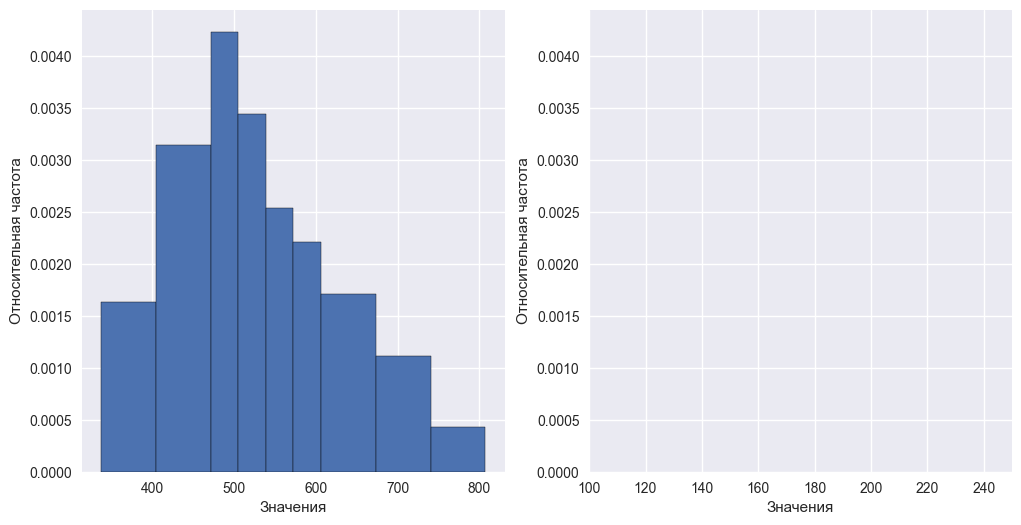

In [77]:
mpl.rcParams["text.usetex"] = False
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].hist(X, bins=bin_edges, edgecolor="black", density=True)
axes[0].set_xlabel("Значения")
axes[0].set_ylabel("Относительная частота")

axes[1].hist(X, bins=bin_edges, edgecolor="black", density=True)
axes[1].set_xlabel("Значения")
axes[1].set_ylabel("Относительная частота")
plt.xlim(100, 250)

plt.show()

In [80]:
mprint(
    f"Число интервалов: {k}",
    f"Ширина интервалов: от {np.diff(bin_edges).min():.2f} до {np.diff(bin_edges).max():.2f}",
)

Число интервалов: 11

Ширина интервалов: от 33.42 до inf

In [79]:
groups = pd.DataFrame(index=pd.Index(range(1, len(bin_edges)), name="Номер интервала"))
groups["low edge"] = bin_edges[:-1]
groups["high edge"] = bin_edges[1:]
groups["frequency"] = groups.apply(
    lambda row: ((X >= row["low edge"]) & (X < row["high edge"])).sum(), axis=1
)
groups["relative frequency"] = groups["frequency"] / n
groups["expected probability"] = expected_frequencies / n
groups

,low edge,high edge,frequency,relative frequency,expected probability
Номер интервала,,,,,
1,-inf,337.181818,28,0.026095,0.053979
2,337.181818,404.363636,118,0.109972,0.095896
3,404.363636,471.545455,227,0.211556,0.170553
4,471.545455,505.209807,153,0.142591,0.107895
5,505.209807,538.727273,124,0.115564,0.113079
6,538.727273,572.150920,91,0.084809,0.109509
7,572.150920,605.909091,80,0.074557,0.099072
8,605.909091,673.090909,123,0.114632,0.143434
9,673.090909,740.272727,80,0.074557,0.071850


In [65]:
groups = pd.DataFrame(index=pd.Index(range(1, len(bin_edges)), name="Номер интервала"))
groups["low edge"] = bin_edges[:-1]
groups["high edge"] = bin_edges[1:]
groups["frequency"] = groups.apply(
    lambda row: ((X >= row["low edge"]) & (X < row["high edge"])).sum(), axis=1
)
groups["relative frequency"] = groups["frequency"] / n
groups["expected probability"] = expected_frequencies / n
groups

,low edge,high edge,frequency,relative frequency,expected probability
Номер интервала,,,,,
1,-10000.000000,337.181818,28,0.026095,0.053979
2,337.181818,404.363636,118,0.109972,0.095896
3,404.363636,471.545455,227,0.211556,0.170553
4,471.545455,505.209807,153,0.142591,0.107895
5,505.209807,538.727273,124,0.115564,0.113079
6,538.727273,572.150920,91,0.084809,0.109509
7,572.150920,605.909091,80,0.074557,0.099072
8,605.909091,673.090909,123,0.114632,0.143434
9,673.090909,740.272727,80,0.074557,0.071850


In [66]:
print(dataframe_to_markdown(groups))

| Номер интервала | low edge | high edge | frequency | relative frequency | expected probability |
|---|---|---|---|---|---|
| 1 | -10000.0 | 337.18 | 28.0 | 0.03 | 0.05 |
| 2 | 337.18 | 404.36 | 118.0 | 0.11 | 0.1 |
| 3 | 404.36 | 471.55 | 227.0 | 0.21 | 0.17 |
| 4 | 471.55 | 505.21 | 153.0 | 0.14 | 0.11 |
| 5 | 505.21 | 538.73 | 124.0 | 0.12 | 0.11 |
| 6 | 538.73 | 572.15 | 91.0 | 0.08 | 0.11 |
| 7 | 572.15 | 605.91 | 80.0 | 0.07 | 0.1 |
| 8 | 605.91 | 673.09 | 123.0 | 0.11 | 0.14 |
| 9 | 673.09 | 740.27 | 80.0 | 0.07 | 0.07 |
| 10 | 740.27 | 807.45 | 31.0 | 0.03 | 0.03 |
| 11 | 807.45 | 10000.0 | 18.0 | 0.02 | 0.01 |



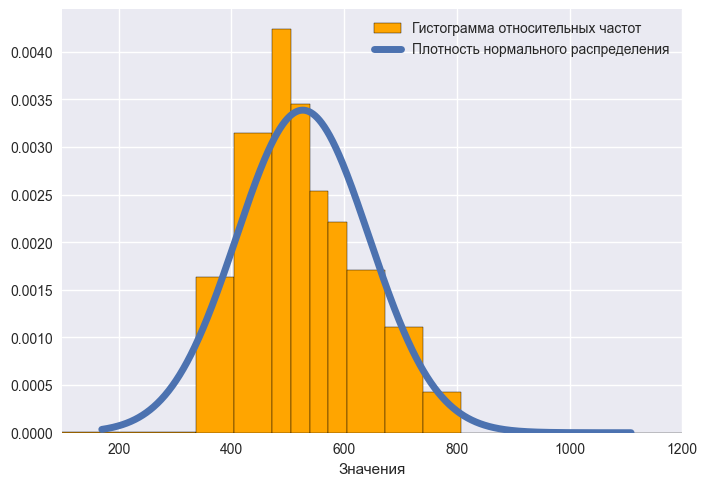

In [67]:
grid = np.linspace(X.min() - 100, X.max() + 100, 1000)
plt.hist(
    X,
    bins=bin_edges,
    edgecolor="black",
    density=True,
    label="Гистограмма относительных частот",
    color="orange",
)

plt.plot(
    grid,
    stats.norm.pdf(grid, loc=X.mean(), scale=X.std(ddof=1)),
    label="Плотность нормального распределения",
    lw=5,
)
plt.legend()
plt.xlim(100, 1200)
plt.xlabel("Значения")
plt.show()

In [68]:
alphas = [0.01, 0.05, 0.1]

obs = groups["frequency"].to_numpy(dtype=float)
exp = np.asarray(expected_frequencies, dtype=float)

exp *= obs.sum() / exp.sum()

z, p_value = stats.chisquare(groups["frequency"], expected_frequencies, ddof=2)
mprint(
    r"### $\chi^2$-test",
    f"$H_0: F_X(x) = N(\\mu, \\sigma)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### $\chi^2$-test

$H_0: F_X(x) = N(\mu, \sigma)$

$z_{выб} =$ 67.96

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

## 4.2 Критерий Харке-Бера

In [25]:
z, p_value = stats.jarque_bera(X)
mprint(
    r"### Jarque-Bera test",
    f"$H_0: F_X(x) = N(\\mu, \\sigma)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Jarque-Bera test

$H_0: F_X(x) = N(\mu, \sigma)$

$z_{выб} =$ 94.94

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

# 5. Проверка однородности выборок

In [82]:
X, Y = data("5")

X.head(), Y.head()

(0    454
 1    686
 2    533
 3    612
 4    442
 Name: A5, dtype: int64,
 0    382
 1    560
 2    494
 3    507
 4    369
 Name: A6, dtype: int64)

In [83]:
print(n1 := len(X), n2 := len(Y))

1073 1073


## 5.1 Критерий знаков

In [84]:
def sign_test(X, Y):
    if len(X) != len(Y):
        raise ValueError("Длины выборок должны совпадать")
    n = len(X)
    k = sum(X > Y)
    z = (k - n / 2) / m.sqrt(n / 4)
    p_value = 2 * min(stats.norm.cdf(z), 1 - stats.norm.cdf(z))
    return z, p_value

alphas = [0.01, 0.05, 0.1]

z, p_value = sign_test(X, Y)
mprint(
    r"### Sign test",
    f"$H_0: F_X(x) = F_Y(x)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Sign test

$H_0: F_X(x) = F_Y(x)$

$z_{выб} =$ 32.39

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

## 5.2 Критерий $\chi^2$

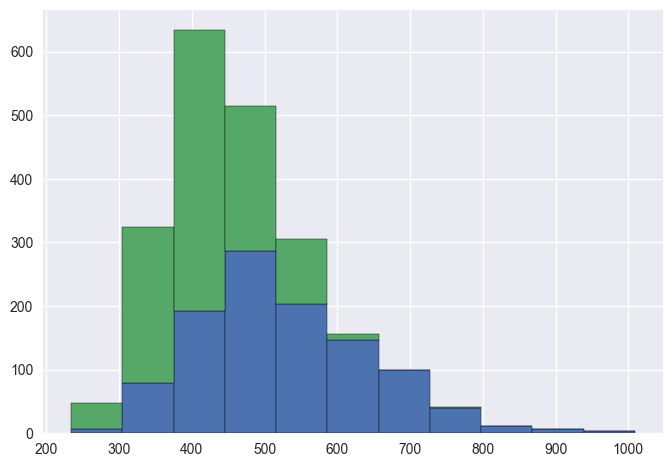

In [85]:
k = round(1 + 3.322 * m.log10(n))
frequences, bin_edges, _ = plt.hist((X, Y), bins=k, edgecolor="black", stacked=True)
plt.show()

In [86]:
frequences[1]

array([ 47., 325., 634., 515., 306., 156., 100.,  41.,  11.,   7.,   4.])

In [87]:
def merge_interval(bin_edges, frequences1, frequences2, i):
    # Объединяем два интервала в зависимости от их индексов.
    if i == 0:  # Крайний левый интервал
        bin_edges.pop(i + 1)
        frequences1[i + 1] += frequences1[i]
        frequences2[i + 1] += frequences2[i]
    elif i == len(bin_edges) - 2:  # Крайний правый интервал
        bin_edges.pop(i)
        frequences1[i - 1] += frequences1[i]
        frequences2[i - 1] += frequences2[i]
    else:  # Объединяем с соседом c наименьшим expected_frequencies
        if (
            frequences1[i - 1] + frequences2[i - 1]
            < frequences1[i + 1] + frequences2[i + 1]
        ):
            bin_edges.pop(i)
            frequences1[i - 1] += frequences1[i]
            frequences2[i - 1] += frequences2[i]
        else:
            bin_edges.pop(i + 1)
            frequences1[i + 1] += frequences1[i]
            frequences2[i + 1] += frequences2[i]
    frequences1.pop(i)
    frequences2.pop(i)

In [88]:
def adjust_intervals(bin_edges, X1, X2, k=None):
    frequences1, _ = np.histogram(X1, bins=bin_edges)
    frequences2, _ = np.histogram(X2, bins=bin_edges)
    frequences1 = frequences1.tolist()
    frequences2 = frequences2.tolist()

    # Слияние интервалов с малой частотой попадания
    i = 0
    while True:
        if frequences1[i] + frequences2[i] < 5:
            merge_interval(bin_edges, frequences1, frequences2, i)
            i -= 1

        i += 1
        if i >= len(bin_edges) - 1:
            break

    # Разбиение интервалов с максимальной частотой попадания
    if k is not None:
        while len(bin_edges) < k + 1:
            total_frequency = [x + y for x, y in zip(frequences1, frequences2)]
            max_frequency = max(total_frequency)

            # если максимальная частота меньше 5, то нельзя подразбивать интервалы
            if max_frequency < 10:
                break

            max_index = total_frequency.index(max_frequency)
            a, b = bin_edges[max_index : max_index + 2]

            # Находим такое c, что частота попадания в интервалах (a, c) и (c, b) как минимум 5
            c = (a + b) / 2

            frequences1[max_index] = ((X1 >= a) & (X1 < c)).sum()
            frequences2[max_index] = ((X2 >= a) & (X2 < c)).sum()
            frequences1.insert(max_index + 1, ((X1 >= c) & (X1 < b)).sum())
            frequences2.insert(max_index + 1, ((X2 >= c) & (X2 < b)).sum())
            bin_edges.insert(max_index + 1, c)

    return bin_edges, frequences1, frequences2

In [89]:
bin_edges, frequences1, frequences2 = adjust_intervals(bin_edges.tolist(), X, Y, k=k)
np.array(frequences1) + np.array(frequences2)

array([ 47, 325, 293, 341, 515, 306, 156, 100,  41,  11,  11])

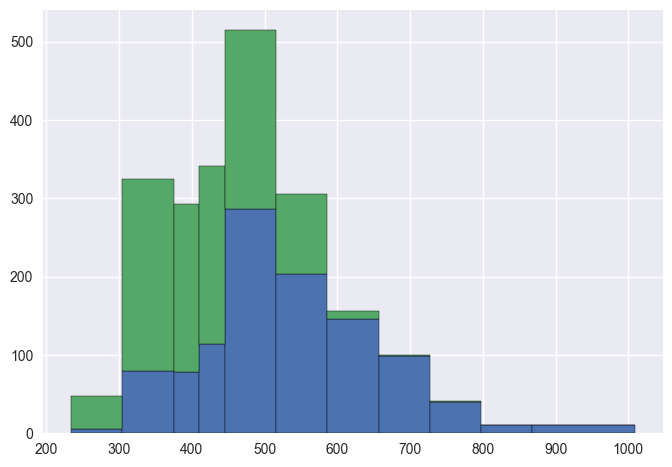

In [90]:
frequences, bin_edges, _ = plt.hist(
    (X, Y), bins=bin_edges, edgecolor="black", stacked=True
)
plt.show()

In [91]:
frequences[1]

array([ 47., 325., 293., 341., 515., 306., 156., 100.,  41.,  11.,  11.])

In [92]:
mprint(
    f"Число интервалов: {k}",
    f"Ширина интервалов: от {np.diff(bin_edges).min():.2f} до {np.diff(bin_edges).max():.2f}",
)

Число интервалов: 11

Ширина интервалов: от 35.23 до 140.91

In [93]:
groups = pd.DataFrame(index=pd.Index(range(1, len(bin_edges)), name="Номер интервала"))
groups["low edge"] = bin_edges[:-1]
groups["high edge"] = bin_edges[1:]
groups["frequency1"] = frequences[0]
groups["frequency2"] = frequences[1] - frequences[0]
groups["relative frequency1"] = groups["frequency1"] / n1
groups["relative frequency2"] = groups["frequency2"] / n2

groups

,low edge,high edge,frequency1,frequency2,relative frequency1,relative frequency2
Номер интервала,,,,,,
1,234.000000,304.454545,6.0,41.0,0.005592,0.038211
2,304.454545,374.909091,79.0,246.0,0.073625,0.229264
3,374.909091,410.136364,78.0,215.0,0.072693,0.200373
4,410.136364,445.363636,114.0,227.0,0.106244,0.211556
5,445.363636,515.818182,286.0,229.0,0.266542,0.213420
6,515.818182,586.272727,203.0,103.0,0.189189,0.095993
7,586.272727,656.727273,146.0,10.0,0.136067,0.009320
8,656.727273,727.181818,99.0,1.0,0.092265,0.000932
9,727.181818,797.636364,40.0,1.0,0.037279,0.000932


In [94]:
print(dataframe_to_markdown(groups))

| Номер интервала | low edge | high edge | frequency1 | frequency2 | relative frequency1 | relative frequency2 |
|---|---|---|---|---|---|---|
| 1 | 234.0 | 304.45 | 6.0 | 41.0 | 0.01 | 0.04 |
| 2 | 304.45 | 374.91 | 79.0 | 246.0 | 0.07 | 0.23 |
| 3 | 374.91 | 410.14 | 78.0 | 215.0 | 0.07 | 0.2 |
| 4 | 410.14 | 445.36 | 114.0 | 227.0 | 0.11 | 0.21 |
| 5 | 445.36 | 515.82 | 286.0 | 229.0 | 0.27 | 0.21 |
| 6 | 515.82 | 586.27 | 203.0 | 103.0 | 0.19 | 0.1 |
| 7 | 586.27 | 656.73 | 146.0 | 10.0 | 0.14 | 0.01 |
| 8 | 656.73 | 727.18 | 99.0 | 1.0 | 0.09 | 0.0 |
| 9 | 727.18 | 797.64 | 40.0 | 1.0 | 0.04 | 0.0 |
| 10 | 797.64 | 868.09 | 11.0 | 0.0 | 0.01 | 0.0 |
| 11 | 868.09 | 1009.0 | 11.0 | 0.0 | 0.01 | 0.0 |



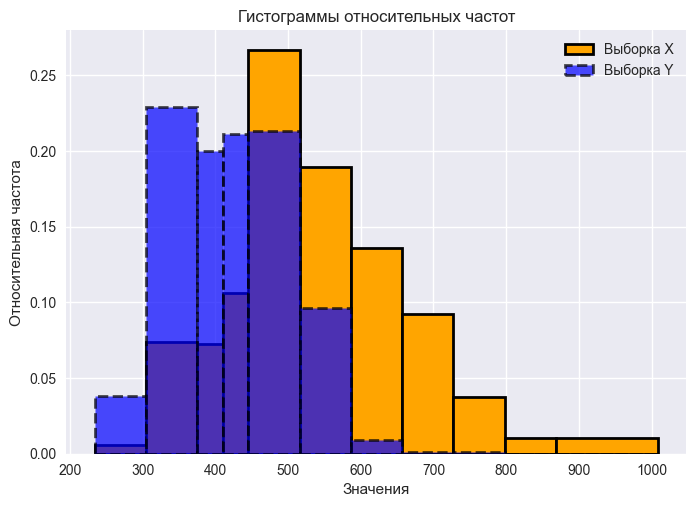

In [95]:
plt.bar(
    (groups["low edge"] + groups["high edge"]) / 2,
    groups["relative frequency1"],
    width=groups["high edge"] - groups["low edge"],
    edgecolor="black",
    label="Выборка X",
    color="orange",
    lw=2,
)

plt.bar(
    (groups["low edge"] + groups["high edge"]) / 2,
    groups["relative frequency2"],
    width=groups["high edge"] - groups["low edge"],
    edgecolor="black",
    label="Выборка Y",
    alpha=0.7,
    linestyle="--",
    lw=2,
    color="blue",
)
plt.legend()
plt.title("Гистограммы относительных частот")
plt.xlabel("Значения")
plt.ylabel("Относительная частота")
plt.show()

In [96]:
def chi2_2samp(frequencies1, frequencies2):
    if len(frequencies1) != len(frequencies2):
        raise ValueError("Длины выборок должны совпадать")
    k = len(frequencies1)
    n = sum(frequencies1)
    m = sum(frequencies2)
    z = (
        n
        * m
        * sum(
            (frequencies1 / n - frequencies2 / m) ** 2 / (frequencies1 + frequencies2)
        )
    )
    p_value = stats.chi2.sf(z, df=k - 1)
    return z, p_value

In [98]:
alphas = [0.01, 0.05, 0.1]

z, p_value = chi2_2samp(groups["frequency1"], groups["frequency2"])
mprint(
    r"### $\chi^2$-test",
    f"$H_0: F_X(x) = F_Y(x)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### $\chi^2$-test

$H_0: F_X(x) = F_Y(x)$

$z_{выб} =$ 526.07

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

#  6. Таблицы сопряжённости

In [42]:
X, Y = data("6")
X.head(), Y.head()

(0    IIB
 1      I
 2    IIA
 3    IIA
 4    IIA
 Name: A4, dtype: object,
 0    N
 1    Y
 2    N
 3    Y
 4    N
 Name: A9, dtype: object)

In [43]:
print(n1 := len(X), n2 := len(Y))
if n1 == n2:
    n = n1

1073 1073


In [44]:
df = pd.DataFrame({"X": X, "Y": Y})
df

,X,Y
0,IIB,N
1,I,Y
2,IIA,N
3,IIA,Y
4,IIA,N
...,...,...
1068,IIB,N
1069,I,Y
1070,IIB,N
1071,IIB,N


In [45]:
emperical_table = pd.crosstab(df["X"], df["Y"], margins=True)
emperical_table

Y,N,Y,All
X,,,
I,13,167,180
IIA,177,182,359
IIB,411,123,534
All,601,472,1073


In [46]:
print(dataframe_to_markdown(emperical_table))

| X\Y | N | Y | All |
|---|---|---|---|
| I | 13 | 167 | 180 |
| IIA | 177 | 182 | 359 |
| IIB | 411 | 123 | 534 |
| All | 601 | 472 | 1073 |



In [47]:
V1 = np.array(emperical_table.iloc[:-1, -1])
V1 = np.atleast_2d(V1).T

In [48]:
V2 = np.array(emperical_table.iloc[-1][:-1])
V2

array([601, 472])

In [49]:
V2 = np.atleast_2d(V2)

In [50]:
A = np.dot(V1, V2)
A

array([[108180,  84960],
       [215759, 169448],
       [320934, 252048]])

In [51]:
theoretical_table = pd.DataFrame(
    A / n,
    index=emperical_table.index[:-1],
    columns=emperical_table.columns[:-1],
)
theoretical_table

Y,N,Y
X,,
I,100.820130,79.179870
IIA,201.080149,157.919851
IIB,299.099720,234.900280


In [52]:
theoretical_table["All"] = theoretical_table.sum(axis=1)
theoretical_table.loc["All"] = theoretical_table.sum()
theoretical_table

Y,N,Y,All
X,,,
I,100.820130,79.179870,180.0
IIA,201.080149,157.919851,359.0
IIB,299.099720,234.900280,534.0
All,601.000000,472.000000,1073.0


In [53]:
print(dataframe_to_markdown(theoretical_table))

| X\Y | N | Y | All |
|---|---|---|---|
| I | 100.82 | 79.18 | 180.0 |
| IIA | 201.08 | 157.92 | 359.0 |
| IIB | 299.1 | 234.9 | 534.0 |
| All | 601.0 | 472.0 | 1073.0 |



## Проверить статистические гипотезы

In [54]:
alphas = [0.01, 0.05, 0.1]

res = stats.chi2_contingency(emperical_table.iloc[:-1, :-1])
res

Chi2ContingencyResult(statistic=np.float64(275.62600669302554), pvalue=np.float64(1.4079042246124844e-60), dof=2, expected_freq=array([[100.82013048,  79.17986952],
       [201.08014911, 157.91985089],
       [299.09972041, 234.90027959]]))

In [55]:
z = res.statistic
p = res.pvalue

mprint(
    r"### $\chi^2$-test",
    f"$H_0:\\ F_Y(y \\mid_{{X = x^{{(1)}}}}) = F_Y(y \\mid_{{X = x^{{(2)}}}}) = \\dots = F_Y(y \\mid_{{X = x^{{(k_1)}}}}) = F_Y(y)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p)}")

### $\chi^2$-test

$H_0:\ F_Y(y \mid_{X = x^{(1)}}) = F_Y(y \mid_{X = x^{(2)}}) = \dots = F_Y(y \mid_{X = x^{(k_1)}}) = F_Y(y)$

$z_{выб} =$ 275.63

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

# 7. Дисперсионный анализ

In [56]:
X, Y = data("7")
X.head(), Y.head()

(0    IIB
 1      I
 2    IIA
 3    IIA
 4    IIA
 Name: A4, dtype: object,
 0    454
 1    686
 2    533
 3    612
 4    442
 Name: A5, dtype: int64)

In [57]:
print(n1 := len(X), n2 := len(Y))
if n1 == n2:
    n = n1

1073 1073


In [58]:
print(k := len(X.unique()))

3


## Рассчитать групповые выборочные характеристики

In [59]:
df = pd.DataFrame({"X": X, "Y": Y}).groupby("X")["Y"].apply(np.array).to_frame()
df

,Y
X,
I,"[686, 580, 605, 633, 563, 603, 511, 648, 970, 952, 764, 683, 708, 741, 670, 723, 624, 712, 677, 802, 480, 598, 652, 623, 928, 746, 611, 729, 857, 656, 723, 564, 613, 693, 571, 796, 684, 666, 619, 713, 684, 706, 514, 680, 548, 761, 578, 860, 564, 894, 682, 656, 517, 674, 721, 798, 500, 550, 579, 634, 584, 594, 713, 533, 784, 687, 1009, 664, 903, 688, 735, 704, 798, 703, 638, 574, 651, 683, 603, 777, 662, 657, 603, 663, 580, 576, 782, 540, 558, 562, 497, 446, 854, 665, 701, 610, 460, 661, 785, 587, ...]"
IIA,"[533, 612, 442, 441, 461, 565, 462, 410, 636, 542, 519, 520, 521, 536, 461, 430, 455, 605, 606, 600, 605, 607, 610, 604, 603, 593, 602, 598, 602, 578, 482, 593, 715, 614, 566, 617, 763, 542, 666, 599, 597, 719, 722, 436, 474, 522, 596, 666, 658, 685, 524, 697, 644, 548, 505, 529, 734, 650, 623, 559, 545, 488, 438, 457, 524, 580, 542, 622, 560, 489, 558, 503, 456, 495, 523, 555, 477, 466, 447, 601, 586, 448, 466, 570, 702, 442, 460, 446, 467, 490, 391, 484, 531, 463, 551, 506, 510, 499, 521, 500, ...]"
IIB,"[454, 466, 498, 506, 339, 360, 354, 301, 431, 321, 453, 406, 439, 309, 447, 485, 372, 422, 424, 358, 477, 716, 771, 652, 730, 611, 524, 484, 624, 362, 507, 489, 613, 439, 429, 480, 489, 452, 619, 546, 706, 457, 448, 534, 440, 495, 413, 498, 527, 444, 462, 515, 471, 457, 516, 370, 429, 576, 367, 484, 464, 436, 516, 578, 411, 411, 385, 642, 419, 478, 389, 379, 430, 491, 431, 351, 447, 351, 424, 391, 527, 434, 507, 446, 399, 374, 522, 570, 400, 508, 644, 324, 433, 478, 443, 473, 415, 465, 372, 448, ...]"


In [60]:
groups = pd.DataFrame(index=pd.Index(range(1, k + 1), name="№ п/п"))
groups[r"$x^{(i)}$"] = df.index
groups[r"$n_i$"] = df["Y"].apply(len).values
groups[r"$\overline{y_i}$"] = df["Y"].apply(np.mean).values
groups[r"$s_i^2$"] = df["Y"].apply(np.var, ddof=0).values
groups

,$x^{(i)}$,$n_i$,$\overline{y_i}$,$s_i^2$
№ п/п,,,,
1,I,180,668.527778,11290.938117
2,IIA,359,542.571031,6914.779774
3,IIB,534,467.788390,8966.762337


In [61]:
print(dataframe_to_markdown(groups))

| № п/п | $x^{(i)}$ | $n_i$ | $\overline{y_i}$ | $s_i^2$ |
|---|---|---|---|---|
| 1 | I | 180 | 668.53 | 11290.94 |
| 2 | IIA | 359 | 542.57 | 6914.78 |
| 3 | IIB | 534 | 467.79 | 8966.76 |



## Рассчитать показатели вариации, используемые в дисперсионном анализе

In [62]:
S_general = float(Y.var(ddof=0))
S_inside = 1 / n * sum(groups[r"$n_i$"] * groups[r"$s_i^2$"])
S_between = (
    1 / n * sum(groups[r"$n_i$"] * (groups[r"$\overline{y_i}$"] - Y.mean()) ** 2)
)

S_general_unbiased = S_general * n / (n - 1)
S_inside_unbiased = S_inside * n / (n - k)
S_between_unbiased = S_between * n / (k - 1)

mprint(
    f"$\\tilde{{D}}_{{\\text{{межгр}}}} = {S_between:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{внутр}}}} = {S_inside:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{общ}}}} = {S_general:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{межгр, несмещ}}}} = {S_between_unbiased:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{внутр, несмещ}}}} = {S_inside_unbiased:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{общ, несмещ}}}} = {S_general_unbiased:.2f}$",
)

$\tilde{D}_{\text{межгр}} = 5185.82$

$\tilde{D}_{\text{внутр}} = 8670.11$

$\tilde{D}_{\text{общ}} = 13855.93$

$\tilde{D}_{\text{межгр, несмещ}} = 2782194.04$

$\tilde{D}_{\text{внутр, несмещ}} = 8694.42$

$\tilde{D}_{\text{общ, несмещ}} = 13868.86$

## Проверить правило сложения дисперсий

In [63]:
mprint(
    f"$\\tilde{{D}}_{{\\text{{межгр}}}} = {S_between:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{внутр}}}} = {S_inside:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{общ}}}} = {S_general:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{межгр}}}} + \\tilde{{D}}_{{\\text{{внутр}}}} = {S_between + S_inside:.2f}$",
)
print(S_between + S_inside - S_general < 1e-10)

$\tilde{D}_{\text{межгр}} = 5185.82$

$\tilde{D}_{\text{внутр}} = 8670.11$

$\tilde{D}_{\text{общ}} = 13855.93$

$\tilde{D}_{\text{межгр}} + \tilde{D}_{\text{внутр}} = 13855.93$

True


## Рассчитать показатели тесноты связи между факторным и результативным признаками

In [64]:
eta_squared = S_between / S_general

eta = m.sqrt(eta_squared)

mprint(
    f"$\\tilde{{\\eta^2}} = {eta_squared:.2f}$",
    f"$\\tilde{{\\eta}} = {eta:.2f}$",
)

$\tilde{\eta^2} = 0.37$

$\tilde{\eta} = 0.61$

## Проверить статистическую гипотезу дисперсионного анализа

In [65]:
alphas = [0.01, 0.05, 0.1]

z, p_value = stats.f_oneway(*df["Y"])

mprint(
    r"### ANOVA",
    f"$H_0: m_1 = m_2 = m_3$",
    f"$z_{{выб}} = {z:.2f}$",
    f"$p = {p_value:.2f}$",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### ANOVA

$H_0: m_1 = m_2 = m_3$

$z_{выб} = 320.00$

$p = 0.00$

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

# 8. Корреляционный анализ

## 8.1 Расчёт парных коэффициентов корреляции

In [66]:
X, Y = data("8.1")
X.head(), Y.head()

(0    454
 1    686
 2    533
 3    612
 4    442
 Name: A5, dtype: int64,
 0    382
 1    560
 2    494
 3    507
 4    369
 Name: A6, dtype: int64)

In [67]:
print(n1 := len(X), n2 := len(Y))

if n1 == n2:
    n = n1

1073 1073


In [68]:
rho_XY = stats.pearsonr(X, Y)[0]
rho_sp_XY = stats.spearmanr(X, Y)[0]
tau_XY = stats.kendalltau(X, Y)[0]

mprint(
    f"$\\rho_{{XY}} = {rho_XY:.2f}$",
    f"$\\rho^{{(sp)}}_{{XY}} = {rho_sp_XY:.2f}$",
    f"$\\tau_{{XY}} = {tau_XY:.2f}$",
)

$\rho_{XY} = 0.94$

$\rho^{(sp)}_{XY} = 0.95$

$\tau_{XY} = 0.82$

### Рассчитать доверительные интервалы для линейного коэффициента корреляции

In [80]:
intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"],
        name="Граница доверительного интервала",
    )
)

alphas = [0.01, 0.05, 0.1]

# rho_XY = rho*_{XY} (выборочный коэффициент корреляции)
# n = объем выборки

for alpha in alphas:
    u = stats.norm.ppf(1 - alpha / 2)  # u_{1-α/2}

    delta = (rho_XY * (1 - rho_XY**2)) / (2 * n)
    half_width = u * (1 - rho_XY**2) / m.sqrt(n)

    lower = rho_XY + delta - half_width
    upper = rho_XY + delta + half_width

    # если хотите гарантировать попадание в [-1, 1], раскомментируйте:
    # lower = max(-1.0, min(1.0, lower))
    # upper = max(-1.0, min(1.0, upper))

    intervals[f"$\\alpha = {alpha}$"] = [lower, upper]

intervals

,$\alpha = 0.01$,$\alpha = 0.05$,$\alpha = 0.1$
Граница доверительного интервала,,,
Нижняя граница,0.934007,0.936099,0.937170
Верхняя граница,0.951511,0.949418,0.948348


### Проверить значимость коэффициентов корреляции

In [69]:
alpha = 0.1

z_rho_XY = rho_XY * m.sqrt(n - 2) / m.sqrt(1 - rho_XY**2)
p_rho_XY = stats.pearsonr(X, Y)[1]

z_rho_sp_XY = rho_sp_XY * m.sqrt(n - 2) / m.sqrt(1 - rho_sp_XY**2)
p_rho_sp_XY = stats.spearmanr(X, Y)[1]

z_tau_XY = tau_XY * m.sqrt(9 * n * (n + 1)) / m.sqrt(2 * (2 * n + 5))
p_tau_XY = stats.kendalltau(X, Y)[1]

mprint(
    r"### Проверка значимости КК",
    r"---",
    r"### $\rho_{XY}$",
    f"$H_0$: $\\rho_{{XY}} = 0$, $H_1$: $\\rho_{{XY}} \\neq 0$",
    f"$z_{{выб}} =$ {z_rho_XY:.2f}, ",
    f"$p =$ {p_rho_XY:.2f}",
    verdict(alpha, p_rho_XY),
    r"---",
    r"### $\rho_{XY}^{(sp)}$",
    f"$H_0$: $\\rho_{{XY}}^{{(sp)}} = 0$, $H_1$: $\\rho_{{XY}}^{{(sp)}} \\neq 0$",
    f"$z_{{выб}} =$ {z_rho_sp_XY:.2f}, ",
    f"$p =$ {p_rho_sp_XY:.2f}",
    verdict(alpha, p_rho_sp_XY),
    r"---",
    r"### $\tau_{XY}$",
    f"$H_0$: $\\tau_{{XY}} = 0$, $H_1$: $\\tau_{{XY}} \\neq 0$",
    f"$z_{{выб}} =$ {z_tau_XY:.2f}, ",
    f"$p =$ {p_tau_XY:.2f}",
    verdict(alpha, p_tau_XY),
)

### Проверка значимости КК

---

### $\rho_{XY}$

$H_0$: $\rho_{XY} = 0$, $H_1$: $\rho_{XY} \neq 0$

$z_{выб} =$ 92.48, 

...

### $\tau_{XY}$

$H_0$: $\tau_{XY} = 0$, $H_1$: $\tau_{XY} \neq 0$

$z_{выб} =$ 40.30, 

$p =$ 0.00

$H_0$ отклоняется

## 8.2 Расчёт множественных коэффициентов корреляции

In [70]:
X = pd.concat(data("8.2"), axis=1)
X.head()

,A5,A6,A7
0,454,382,362
1,686,560,432
2,533,494,329
3,612,507,414
4,442,369,310


In [71]:
print(n := len(X))

1073


In [72]:
print(k := X.shape[1])

3


### Рассчитать матрицу ранговых коэффициентов корреляции по Кендаллу

In [73]:
kendall_matrix = pd.DataFrame(
    np.zeros((X.shape[1], X.shape[1])), index=X.columns, columns=X.columns
)
kendall_matrix.index.name = "Признак"
kendall_matrix.columns.name = "Признак"

p_value_matrix = pd.DataFrame(
    np.zeros((X.shape[1], X.shape[1])), index=X.columns, columns=X.columns
)
p_value_matrix.index.name = "Признак"
p_value_matrix.columns.name = "Признак"

for i, col1 in enumerate(X.columns):
    for j, col2 in enumerate(X.columns):
        if i >= j:
            tau, p_value = stats.kendalltau(X[col1], X[col2])
            kendall_matrix.loc[col1, col2] = kendall_matrix.loc[col2, col1] = tau
            p_value_matrix.loc[col1, col2] = p_value_matrix.loc[col2, col1] = p_value

In [74]:
kendall_matrix

Признак,A5,A6,A7
Признак,,,
A5,1.000000,0.820784,0.765362
A6,0.820784,1.000000,0.801992
A7,0.765362,0.801992,1.000000


In [75]:
print(dataframe_to_markdown(kendall_matrix))

| Признак\Признак | A5 | A6 | A7 |
|---|---|---|---|
| A5 | 1.0 | 0.82 | 0.77 |
| A6 | 0.82 | 1.0 | 0.8 |
| A7 | 0.77 | 0.8 | 1.0 |



### Рассчитать матрицу значений $p$-value для ранговых коэффициентов корреляции по Кендаллу

In [76]:
p_value_matrix

Признак,A5,A6,A7
Признак,,,
A5,0.000000e+00,0.0,3.560719e-306
A6,0.000000e+00,0.0,0.000000e+00
A7,3.560719e-306,0.0,0.000000e+00


### Рассчитать точечную оценку коэффициента конкордации

In [77]:
ranks = X.rank()
ranks.columns.name = "Выборка"
ranks.index.name = "№ объекта"
ranks

Выборка,A5,A6,A7
№ объекта,,,
0,310.5,330.5,625.0
1,973.0,1045.5,993.0
2,633.0,909.5,350.0
3,836.5,937.0,927.0
4,265.5,255.0,220.0
...,...,...,...
1068,156.5,132.5,146.0
1069,639.5,641.5,616.0
1070,261.5,335.0,432.0


In [78]:
W = 12 / (k**2 * (n**3 - n)) * sum((ranks.sum(axis=1) - k * (n + 1) / 2) ** 2)

print(f"{W = :.2f}")

W = 0.96


### Проверить значимость коэффициента конкордации

In [79]:
alphas = [0.01, 0.05, 0.1]

z = n * (k - 1) * W
p_value = stats.chi2.sf(z, df=n - 1)

mprint(
    r"### Проверка значимости $W$",
    f"$H_0$: $W = 0$, $H_1$: $W \\neq 0$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Проверка значимости $W$

$H_0$: $W = 0$, $H_1$: $W \neq 0$

$z_{выб} =$ 2060.76

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

# 9. Регрессионный анализ

## 9.1 Простейшая линейная регрессионная модель

In [81]:
X, Y = data("9.1")
X.head(), Y.head()

(0      6
 1     74
 2      9
 3    115
 4     59
 Name: A15, dtype: int64,
 0    567
 1    914
 2    716
 3    825
 4    530
 Name: A10, dtype: int64)

In [9]:
print(n1 := len(X), n2 := len(Y))

if n1 == n2:
    n = n1

1073 1073


In [10]:
k = 2

### 9.1.1. Точечные оценки линейной регрессионной модели

In [11]:
result = stats.linregress(X, Y)
slope, intercept, r_value, p_value, slope_std_err, intercept_std_err = (
    result.slope,
    result.intercept,
    result.rvalue,
    result.pvalue,
    result.stderr,
    result.intercept_stderr,
)

mprint(
    f"$\\tilde{{\\beta_0}} =$ {intercept:.2f}",
    f"$\\tilde{{\\beta_1}} =$ {slope:.2f}",
)

$\tilde{\beta_0} =$ 599.27

$\tilde{\beta_1} =$ 0.56

In [12]:
def f(x):
    return intercept + slope * x


#### Рассчитать показатели вариации, используемые в регрессионном анализе

In [13]:
D_YX = sum((f(X) - Y.mean()) ** 2) / n
D_resY = sum((f(X) - Y) ** 2) / n
D_Y = Y.var(ddof=0)

D_YX_unbiased = D_YX * n / (k - 1)
D_resY_unbiased = D_resY * n / (n - k)
D_Y_unbiased = D_Y * n / (n - 1)

mprint(
    f"$\\tilde{{D}}_{{Y \\mid X}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X, несмещ}} =$ {D_YX_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y ост, несмещ}} =$ {D_resY_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y общ, несмещ}} =$ {D_Y_unbiased:.2f}",
)

$\tilde{D}_{Y \mid X} =$ 6642.54

$\tilde{D}_{Y ост} =$ 16114.63

$\tilde{D}_{Y общ} =$ 22757.17

$\tilde{D}_{Y \mid X, несмещ} =$ 7127440.21

$\tilde{D}_{Y ост, несмещ} =$ 16144.72

$\tilde{D}_{Y общ, несмещ} =$ 22778.40

In [14]:
mprint(
    f"$\\tilde{{D}}_{{Y \\mid X}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X}} + \\tilde{{D}}_{{Y ост}} =$ {D_YX + D_resY:.2f}",
)
print(D_YX + D_resY - D_Y < 1e-10)

$\tilde{D}_{Y \mid X} =$ 6642.54

$\tilde{D}_{Y ост} =$ 16114.63

$\tilde{D}_{Y общ} =$ 22757.17

$\tilde{D}_{Y \mid X} + \tilde{D}_{Y ост} =$ 22757.17

True


#### Рассчитать показатели тесноты связи между факторным и результативным признаками

In [15]:
mprint(
    f"$\\tilde{{R^2}} = {r_value ** 2:.2f}$",
    f"$\\tilde{{R}} = {r_value:.2f}$",
)

$\tilde{R^2} = 0.29$

$\tilde{R} = 0.54$

### 9.1.2. Интервальные оценки линейной регрессионной модели

#### Рассчитать доверительные интервалы для параметров линейной регрессионной модели

In [16]:
intervals = pd.DataFrame(
    index=pd.Index([r"$\beta_0$"] * 2 + [r"$\beta1$"] * 2, name="Параметр")
)
intervals["Границы доверительного интервала"] = [
    "Нижняя граница",
    "Верхняя граница",
] * 2

alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    intervals[f"$\\alpha =$ {alpha}"] = list(
        stats.t.interval(1 - alpha, df=n - 2, scale=intercept_std_err, loc=intercept)
    ) + list(stats.t.interval(1 - alpha, df=n - 2, scale=slope_std_err, loc=slope))

intervals

,Границы доверительного интервала,$\alpha =$ 0.01,$\alpha =$ 0.05,$\alpha =$ 0.1
Параметр,,,,
$\beta_0$,Нижняя граница,587.037015,589.968194,591.465931
$\beta_0$,Верхняя граница,611.505243,608.574065,607.076327
$\beta1$,Нижняя граница,0.490327,0.506775,0.515179
$\beta1$,Верхняя граница,0.627625,0.611177,0.602773


#### Построить диаграмму рассеяния признаков $x$ и $y$. Нанести на диаграмму функцию регрессии $f(x)$, а также нижние и верхние границы линии регрессии $f_{low}(x)$ и $f_{high}(x)$ на уровне значимости $\alpha = 0.1$.

In [17]:
alpha = 0.1

In [18]:
def f_intervals(x):
    std_err = m.sqrt(D_resY_unbiased) * m.sqrt(
        1 / n + (x - X.mean()) ** 2 / (n * X.var(ddof=0))
    )
    return stats.t.interval(
        1 - alpha, df=n - 2, loc=(intercept + slope * x), scale=std_err
    )

In [19]:
table = pd.DataFrame(
    np.column_stack(
        [
            X,
            Y,
            f(X),
            X.apply(f_intervals).apply(lambda x: x[0]),
            X.apply(f_intervals).apply(lambda x: x[1]),
        ]
    ),
    columns=["x", "y", "f(x)", "f_low(x)", "f_high(x)"],
)
table.sort_values("x", inplace=True)
table

,x,y,f(x),f_low(x),f_high(x)
0,6.0,567.0,602.624985,594.967868,610.282102
278,6.0,426.0,602.624985,594.967868,610.282102
344,6.0,499.0,602.624985,594.967868,610.282102
580,6.0,393.0,602.624985,594.967868,610.282102
717,6.0,622.0,602.624985,594.967868,610.282102
...,...,...,...,...,...
1043,918.0,831.0,1112.411016,1076.126969,1148.695062
245,927.0,783.0,1117.441799,1080.769666,1154.113931
432,949.0,843.0,1129.739269,1092.117948,1167.360589
145,981.0,790.0,1147.626498,1108.623285,1186.629711


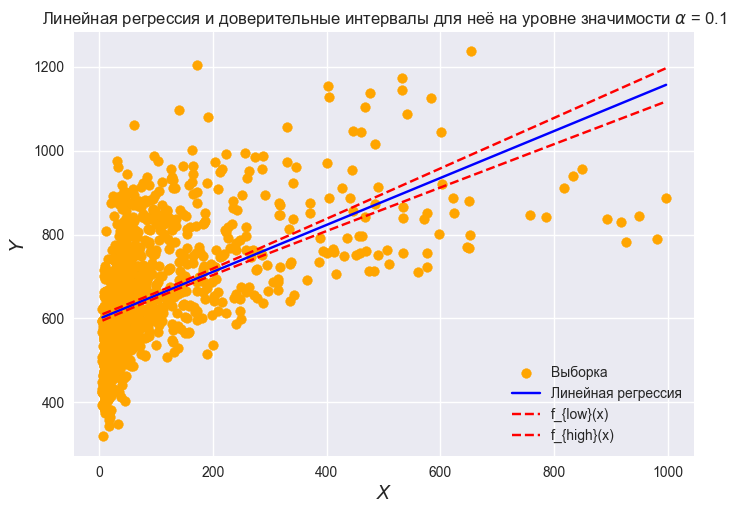

In [29]:
plt.scatter(X, Y, label="Выборка", color="orange")

plt.plot(
    table["x"],
    table["f(x)"],
    label="Линейная регрессия",
    color="blue",
)

plt.plot(
    table["x"], table["f_low(x)"], label=r"f_{low}(x)", color="red", linestyle="--"
)
plt.plot(
    table["x"], table["f_high(x)"], label=r"f_{high}(x)", color="red", linestyle="--"
)

plt.legend()
plt.xlabel("$X$", fontsize=14)
plt.ylabel("$Y$", fontsize=14)
plt.title(
    r"Линейная регрессия и доверительные интервалы для неё на уровне значимости $\alpha$ = 0.1"
)
plt.show()

#### Построить график остатков $\varepsilon(x) = y - f(x)$

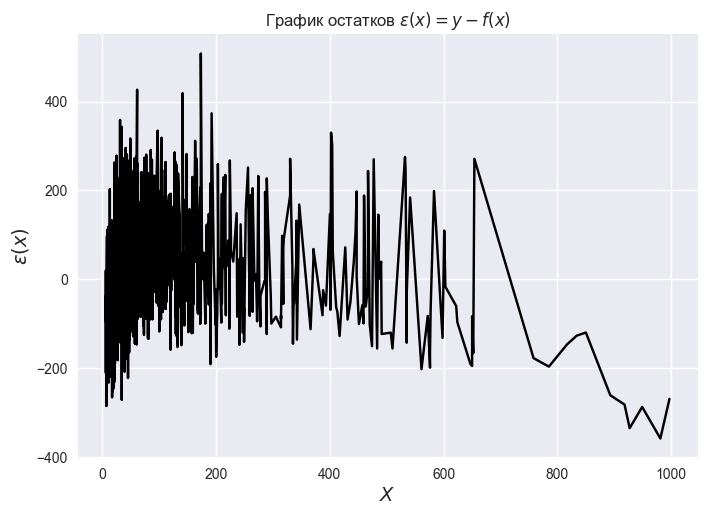

In [30]:
plt.plot(table["x"], table["y"] - table["f(x)"], color="black")
plt.xlabel("$X$", fontsize=14)
plt.ylabel(r"$\varepsilon(x)$", fontsize=14)
plt.title(r"График остатков $\varepsilon(x) = y - f(x)$")
plt.show()

#### Проверить значимость линейной регрессионной модели

In [31]:
alphas = [0.01, 0.05, 0.1]

z = r_value**2 * (n - 2) / (1 - r_value**2)

mprint(
    r"### Проверка значимости линейной регрессии",
    f"$H_0$: $\\beta_1 = 0$, $H_1$: $\\beta_1 \\neq 0$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Проверка значимости линейной регрессии

$H_0$: $\beta_1 = 0$, $H_1$: $\beta_1 \neq 0$

$z_{выб} =$ 441.47

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

## 9.2 Линейная регрессионная модель общего вида

In [32]:
X, Y = data("9.2")
X.head(), Y.head()

(0      6
 1     74
 2      9
 3    115
 4     59
 Name: A15, dtype: int64,
 0    567
 1    914
 2    716
 3    825
 4    530
 Name: A10, dtype: int64)

In [33]:
print(n1 := len(X), n2 := len(Y))

if n1 == n2:
    n = n1

1073 1073


In [ ]:
k = 3

### 9.2.1. Точечные оценки линейной регрессионной модели

In [34]:
X.head()

0      6
1     74
2      9
3    115
4     59
Name: A15, dtype: int64

In [35]:
X.values.reshape(-1, 1)[:5]

design_matrix = np.column_stack([X**i for i in range(3)])
design_matrix[:5]

array([[    1,     6,    36],
       [    1,    74,  5476],
       [    1,     9,    81],
       [    1,   115, 13225],
       [    1,    59,  3481]])

In [36]:
model = sm.OLS(Y, design_matrix).fit()

mprint(
    f"$\\tilde{{\\beta_0}} =$ {model.params.iloc[0]:.2f}",
    f"$\\tilde{{\\beta_1}} =$ {model.params.iloc[1]:.2f}",
    f"$\\tilde{{\\beta_2}} =$ {model.params.iloc[2]:.2f}",
)

$\tilde{\beta_0} =$ 563.01

$\tilde{\beta_1} =$ 1.26

$\tilde{\beta_2} =$ -0.00

In [38]:
predictions = model.predict(design_matrix)

#### Рассчитать показатели вариации, используемые в регрессионном анализе

In [39]:
D_YX = sum((predictions - Y.mean()) ** 2) / n
D_resY = sum((predictions - Y) ** 2) / n
D_Y = Y.var(ddof=0)

D_YX_unbiased = D_YX * n / (k - 1)
D_resY_unbiased = D_resY * n / (n - k)
D_Y_unbiased = D_Y * n / (n - 1)

mprint(
    f"$\\tilde{{D}}_{{Y \\mid X}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X, несмещ}} =$ {D_YX_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y ост, несмещ}} =$ {D_resY_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y общ, несмещ}} =$ {D_Y_unbiased:.2f}",
)

$\tilde{D}_{Y \mid X} =$ 8621.25

$\tilde{D}_{Y ост} =$ 14135.91

$\tilde{D}_{Y общ} =$ 22757.17

$\tilde{D}_{Y \mid X, несмещ} =$ 9250606.47

$\tilde{D}_{Y ост, несмещ} =$ 14162.31

$\tilde{D}_{Y общ, несмещ} =$ 22778.40

In [40]:
mprint(
    f"$\\tilde{{D}}_{{Y \\mid X}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X}} + \\tilde{{D}}_{{Y ост}} = {D_YX + D_resY:.2f}$",
)
print(D_YX + D_resY - D_Y < 1e-10)

$\tilde{D}_{Y \mid X} =$ 8621.25

$\tilde{D}_{Y ост} =$ 14135.91

$\tilde{D}_{Y общ} =$ 22757.17

$\tilde{D}_{Y \mid X} + \tilde{D}_{Y ост} = 22757.17$

True


#### Рассчитать показатели тесноты связи между факторным и результативным признаками

In [41]:
mprint(
    f"$\\tilde{{R^2}} =$ {model.rsquared:.2f}",
    f"$\\tilde{{R}} =$ {m.sqrt(model.rsquared):.2f}",
)

$\tilde{R^2} =$ 0.38

$\tilde{R} =$ 0.62

#### Построить диаграмму рассеяния признаков $x$ и $y$. Нанести на диаграмму функцию регрессии $f(x)$, а также нижние и верхние границы линии регрессии $f_{low}(x)$ и $f_{high}(x)$ на уровне значимости $\alpha = 0.1$.

In [42]:
alpha = 0.1

In [43]:
table = pd.DataFrame(
    np.column_stack(
        [X, Y, predictions, model.get_prediction(design_matrix).conf_int(alpha=alpha)]
    ),
    columns=[
        "x",
        "y",
        "f(x)",
        "f_low(x)",
        "f_high(x)",
    ],
)
table.sort_values("x", inplace=True)
table

,x,y,f(x),f_low(x),f_high(x)
0,6.0,567.0,570.523541,562.149334,578.897748
278,6.0,426.0,570.523541,562.149334,578.897748
344,6.0,499.0,570.523541,562.149334,578.897748
580,6.0,393.0,570.523541,562.149334,578.897748
717,6.0,622.0,570.523541,562.149334,578.897748
...,...,...,...,...,...
1043,918.0,831.0,776.709671,720.183589,833.235752
245,927.0,783.0,769.473734,711.406438,827.541030
432,949.0,843.0,751.023120,689.071128,812.975112
145,981.0,790.0,722.253215,654.357053,790.149377


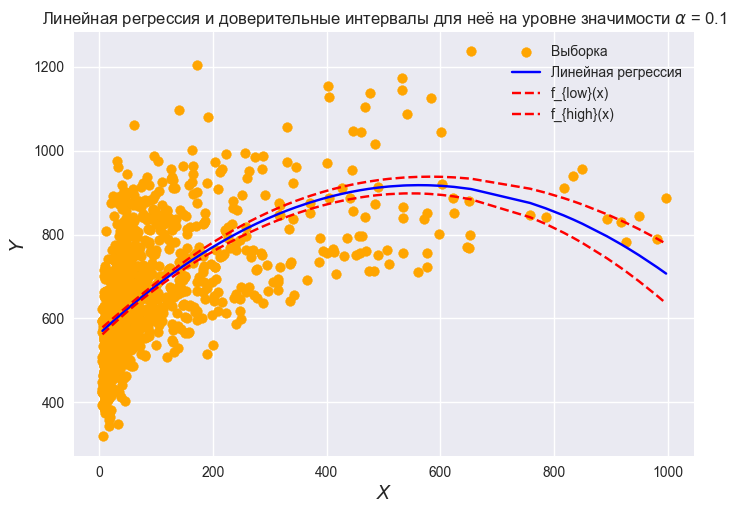

In [44]:
plt.scatter(X, Y, label="Выборка", color="orange")
plt.plot(
    table["x"],
    table["f(x)"],
    label="Линейная регрессия",
    color="blue",
)

plt.plot(
    table["x"], table["f_low(x)"], label=r"f_{low}(x)", color="red", linestyle="--"
)
plt.plot(
    table["x"], table["f_high(x)"], label=r"f_{high}(x)", color="red", linestyle="--"
)

plt.legend()
plt.xlabel("$X$", fontsize=14)
plt.ylabel("$Y$", fontsize=14)
plt.title(
    r"Линейная регрессия и доверительные интервалы для неё на уровне значимости $\alpha$ = 0.1"
)
plt.show()

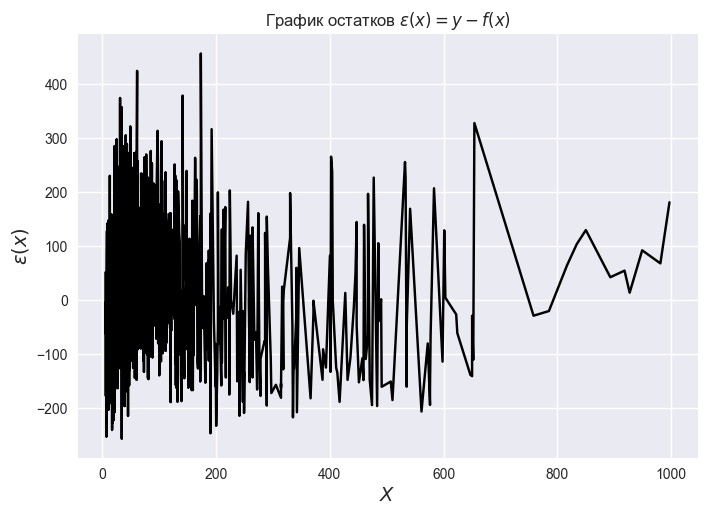

In [45]:
plt.plot(table["x"], table["y"] - table["f(x)"], color="black")
plt.xlabel("$X$", fontsize=14)
plt.ylabel(r"$\varepsilon(x)$", fontsize=14)
plt.title(r"График остатков $\varepsilon(x) = y - f(x)$")
plt.show()

### 9.2.3. Проверка значимости линейной регрессионной модели

In [46]:
alphas = [0.01, 0.05, 0.1]

z = model.fvalue
p_value = model.f_pvalue

mprint(
    r"### Проверка значимости линейной регрессии",
    f"$H_0$: $\\beta_1 = \\beta_2 = 0$, $H_1$: $\\beta_1^2 + \\beta_2^2 > 0$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Проверка значимости линейной регрессии

$H_0$: $\beta_1 = \beta_2 = 0$, $H_1$: $\beta_1^2 + \beta_2^2 > 0$

$z_{выб} =$ 326.29

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

## 9.3 Множественная линейная регрессионная модель

In [47]:
X1, X2, Y = data("9.3")
X1.head(), X2.head(), Y.head()

(0      6
 1     74
 2      9
 3    115
 4     59
 Name: A15, dtype: int64,
 0    454
 1    686
 2    533
 3    612
 4    442
 Name: A5, dtype: int64,
 0    567
 1    914
 2    716
 3    825
 4    530
 Name: A10, dtype: int64)

In [48]:
print(n1 := len(X1), n2 := len(X2), n3 := len(Y))

if n1 == n2 == n3:
    n = n1

1073 1073 1073


In [ ]:
k = 3

### Рассчитать точечные оценки параметров множественной линейной регрессионной модели

In [49]:
vector_X = np.column_stack([X1, X2])
vector_X[:5]

design_matrix = sm.add_constant(vector_X)
design_matrix[:5]

model = sm.OLS(Y, design_matrix).fit()

mprint(
    f"$\\tilde{{\\beta_0}} =$ {model.params.iloc[0]:.2f}",
    f"$\\tilde{{\\beta_1}} =$ {model.params.iloc[1]:.2f}",
    f"$\\tilde{{\\beta_2}} =$ {model.params.iloc[2]:.2f}",
)

$\tilde{\beta_0} =$ -18.84

$\tilde{\beta_1} =$ -0.03

$\tilde{\beta_2} =$ 1.29

In [ ]:
predictions = model.predict(design_matrix)

### Рассчитать показатели вариации, используемые в регрессионном анализе

In [50]:
D_YX = sum((predictions - Y.mean()) ** 2) / n
D_resY = sum((predictions - Y) ** 2) / n
D_Y = Y.var(ddof=0)

D_YX_unbiased = D_YX * n / (k - 1)
D_resY_unbiased = D_resY * n / (n - k)
D_Y_unbiased = D_Y * n / (n - 1)

mprint(
    f"$\\tilde{{D}}_{{Y \\mid X_1, X_2}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X_1, X_2, несмещ}} =$ {D_YX_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y ост, несмещ}} =$ {D_resY_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y общ, несмещ}} =$ {D_Y_unbiased:.2f}",
)

$\tilde{D}_{Y \mid X_1, X_2} =$ 8621.25

$\tilde{D}_{Y ост} =$ 14135.91

$\tilde{D}_{Y общ} =$ 22757.17

$\tilde{D}_{Y \mid X_1, X_2, несмещ} =$ 9250606.47

$\tilde{D}_{Y ост, несмещ} =$ 14162.31

$\tilde{D}_{Y общ, несмещ} =$ 22778.40

In [51]:
mprint(
    f"$\\tilde{{D}}_{{Y \\mid X_1, X_2}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X_1, X_2}} + \\tilde{{D}}_{{Y ост}} = {D_YX + D_resY:.2f}$",
)
print(D_YX + D_resY - D_Y < 1e-10)

$\tilde{D}_{Y \mid X_1, X_2} =$ 8621.25

$\tilde{D}_{Y ост} =$ 14135.91

$\tilde{D}_{Y общ} =$ 22757.17

$\tilde{D}_{Y \mid X_1, X_2} + \tilde{D}_{Y ост} = 22757.17$

True


### Рассчитать показатели тесноты связи между факторными и результативным признаками

In [52]:
mprint(
    f"$\\tilde{{R^2}} =$ {model.rsquared:.2f}",
    f"$\\tilde{{R}} =$ {m.sqrt(model.rsquared):.2f}",
)

$\tilde{R^2} =$ 0.98

$\tilde{R} =$ 0.99